In [ ]:
import pandas as pd

# Lire le fichier Excel
df = pd.read_excel("portefeuille.xlsx")

# Date de valorisation
df["Date de valorisation"] = "20/07/2026"

# Calcul du prix
prix = []

for i in range(len(df)):

    nominal = df.loc[i, "Nominal (MAD)"]

    coupon = df.loc[i, "Taux facial (%)"] / 100

    ytm = df.loc[i, "Taux moyen BKAM (%)"] / 100

    n = (pd.to_datetime(df.loc[i, "Date d'échéance"], dayfirst=True)
         - pd.Timestamp("2026-07-20")).days / 365

    coupon_annuel = nominal * coupon

    p = coupon_annuel * ((1 - (1 + ytm) ** (-n)) / ytm) \
        + nominal / (1 + ytm) ** n

    prix.append(round(p, 2))

df["Prix obligation"] = prix

df.to_excel("Portefeuille_valorise.xlsx", index=False)

print(df)

   ID Type Devise  Nominal (MAD) Date d'émission Date de jouissance  \
0   1  BDT    MAD         100000      2021-08-17         2021-08-17   
1   2  BDT    MAD         100000      2021-11-16         2021-11-16   
2   3  BDT    MAD         100000      2022-02-15         2022-02-15   
3   4  BDT    MAD         100000      2022-09-20         2022-09-20   
4   5  BDT    MAD         100000      2025-04-15         2025-04-15   

  Date d'échéance  Taux facial (%)  Taux moyen BKAM (%) Type remboursement  \
0      2026-08-17             2.25                 2.16            In Fine   
1      2026-11-16             2.25                 2.17            In Fine   
2      2027-02-15             2.30                 2.21            In Fine   
3      2027-09-20             2.30                 2.22            In Fine   
4      2030-04-15             2.75                 2.72            In Fine   

  Fréquence coupon  Quantité d'actifs Date de valorisation  Prix obligation  
0           Annuel        

In [ ]:
import pandas as pd

# Lire le fichier Excel
df = pd.read_excel("Portefeuille_valorise.xlsx")

# Date de valorisation
date_val = pd.Timestamp("2026-07-17")

# Conversion des dates
df["Date de jouissance"] = pd.to_datetime(df["Date de jouissance"], dayfirst=True)
df["Date d'échéance"] = pd.to_datetime(df["Date d'échéance"], dayfirst=True)

coupon_couru = []
clean_price = []

for i in range(len(df)):

    nominal = df.loc[i, "Nominal (MAD)"]
    taux_facial = df.loc[i, "Taux facial (%)"] / 100
    ytm = df.loc[i, "Taux moyen BKAM (%)"] / 100

    # Coupon annuel
    C = nominal * taux_facial

    # Dernière date de coupon
    dernier_coupon = date_val.replace(
        year=date_val.year,
        month=df.loc[i, "Date de jouissance"].month,
        day=df.loc[i, "Date de jouissance"].day
    )

    if dernier_coupon > date_val:
        dernier_coupon = dernier_coupon.replace(year=dernier_coupon.year - 1)

    # Prochaine date de coupon
    prochain_coupon = dernier_coupon.replace(year=dernier_coupon.year + 1)

    # Jours écoulés
    jours_ecoules = (date_val - dernier_coupon).days

    # Jours de la période
    jours_periode = (prochain_coupon - dernier_coupon).days

    # Coupon couru
    AI = C * jours_ecoules / jours_periode

    coupon_couru.append(round(AI, 2))

    # Temps restant jusqu'à l'échéance
    n = (df.loc[i, "Date d'échéance"] - date_val).days / 365

    # Dirty Price
    dirty = C * ((1 - (1 + ytm) ** (-n)) / ytm) + nominal / (1 + ytm) ** n

    # Clean Price
    clean = dirty - AI

    clean_price.append(round(clean, 2))

# Ajouter les colonnes
df["Coupon couru"] = coupon_couru
df["Clean Price"] = clean_price

# Sauvegarder
df.to_excel("Portefeuille_valorise.xlsx", index=False)

print(df)

   ID Type Devise  Nominal (MAD) Date d'émission Date de jouissance  \
0   1  BDT    MAD         100000      2021-08-17         2021-08-17   
1   2  BDT    MAD         100000      2021-11-16         2021-11-16   
2   3  BDT    MAD         100000      2022-02-15         2022-02-15   
3   4  BDT    MAD         100000      2022-09-20         2022-09-20   
4   5  BDT    MAD         100000      2025-04-15         2025-04-15   

  Date d'échéance  Taux facial (%)  Taux moyen BKAM (%) Type remboursement  \
0      2026-08-17             2.25                 2.16            In Fine   
1      2026-11-16             2.25                 2.17            In Fine   
2      2027-02-15             2.30                 2.21            In Fine   
3      2027-09-20             2.30                 2.22            In Fine   
4      2030-04-15             2.75                 2.72            In Fine   

  Fréquence coupon  Quantité d'actifs Date de valorisation  Prix obligation  \
0           Annuel       

In [ ]:
import pandas as pd
import math

# Lire le fichier existant
df = pd.read_excel("Portefeuille_valorise.xlsx")

# Date de valorisation
date_val = pd.Timestamp("2026-07-17")

# Conversion des dates
df["Date d'échéance"] = pd.to_datetime(df["Date d'échéance"], dayfirst=True)

durations = []

for i in range(len(df)):

    nominal = df.loc[i, "Nominal (MAD)"]
    coupon_rate = df.loc[i, "Taux facial (%)"] / 100
    ytm = df.loc[i, "Taux moyen BKAM (%)"] / 100

    # Dirty Price déjà calculé
    prix = df.loc[i, "Prix obligation"]

    # Coupon annuel
    C = nominal * coupon_rate

    # Nombre d'années restantes (arrondi au supérieur)
    n = math.ceil(
        (df.loc[i, "Date d'échéance"] - date_val).days / 365
    )

    numerateur = 0

    for t in range(1, n + 1):

        if t == n:
            flux = C + nominal
        else:
            flux = C

        valeur_actuelle = flux / ((1 + ytm) ** t)

        numerateur += t * valeur_actuelle

    duration = numerateur / prix

    durations.append(round(duration, 4))

# Ajouter la colonne
df["Duration (années)"] = durations

# Sauvegarder dans le même fichier
df.to_excel("Portefeuille_valorise.xlsx", index=False)

print(df)

   ID Type Devise  Nominal (MAD) Date d'émission Date de jouissance  \
0   1  BDT    MAD         100000      2021-08-17         2021-08-17   
1   2  BDT    MAD         100000      2021-11-16         2021-11-16   
2   3  BDT    MAD         100000      2022-02-15         2022-02-15   
3   4  BDT    MAD         100000      2022-09-20         2022-09-20   
4   5  BDT    MAD         100000      2025-04-15         2025-04-15   

  Date d'échéance  Taux facial (%)  Taux moyen BKAM (%) Type remboursement  \
0      2026-08-17             2.25                 2.16            In Fine   
1      2026-11-16             2.25                 2.17            In Fine   
2      2027-02-15             2.30                 2.21            In Fine   
3      2027-09-20             2.30                 2.22            In Fine   
4      2030-04-15             2.75                 2.72            In Fine   

  Fréquence coupon  Quantité d'actifs Date de valorisation  Prix obligation  \
0           Annuel       

In [ ]:
import pandas as pd

# Lire le fichier existant
df = pd.read_excel("Portefeuille_valorise.xlsx")

sensibilite = []

for i in range(len(df)):

    duration = df.loc[i, "Duration (années)"]

    ytm = df.loc[i, "Taux moyen BKAM (%)"] / 100

    S = duration / (1 + ytm)

    sensibilite.append(round(S, 4))

# Ajouter la colonne
df["Sensibilité"] = sensibilite

# Sauvegarder le même fichier
df.to_excel("Portefeuille_valorise.xlsx", index=False)

print(df)

   ID Type Devise  Nominal (MAD) Date d'émission Date de jouissance  \
0   1  BDT    MAD         100000      2021-08-17         2021-08-17   
1   2  BDT    MAD         100000      2021-11-16         2021-11-16   
2   3  BDT    MAD         100000      2022-02-15         2022-02-15   
3   4  BDT    MAD         100000      2022-09-20         2022-09-20   
4   5  BDT    MAD         100000      2025-04-15         2025-04-15   

  Date d'échéance  Taux facial (%)  Taux moyen BKAM (%) Type remboursement  \
0      2026-08-17             2.25                 2.16            In Fine   
1      2026-11-16             2.25                 2.17            In Fine   
2      2027-02-15             2.30                 2.21            In Fine   
3      2027-09-20             2.30                 2.22            In Fine   
4      2030-04-15             2.75                 2.72            In Fine   

  Fréquence coupon  Quantité d'actifs Date de valorisation  Prix obligation  \
0           Annuel       

In [ ]:
import pandas as pd
import math

# Lire le fichier
df = pd.read_excel("Portefeuille_valorise.xlsx")

date_val = pd.Timestamp("2026-07-17")

# Conversion des dates
df["Date d'échéance"] = pd.to_datetime(df["Date d'échéance"], dayfirst=True)

convexites = []

for i in range(len(df)):

    nominal = df.loc[i, "Nominal (MAD)"]

    coupon_rate = df.loc[i, "Taux facial (%)"] / 100

    ytm = df.loc[i, "Taux moyen BKAM (%)"] / 100

    prix = df.loc[i, "Prix obligation"]      # Dirty Price

    C = nominal * coupon_rate

    n = math.ceil(
        (df.loc[i, "Date d'échéance"] - date_val).days / 365
    )

    somme = 0

    for t in range(1, n + 1):

        if t == n:
            flux = C + nominal
        else:
            flux = C

        somme += flux * t * (t + 1) / ((1 + ytm) ** (t + 2))

    convexite = somme / prix

    convexites.append(round(convexite, 4))

df["Convexité"] = convexites

df.to_excel("Portefeuille_valorise.xlsx", index=False)

print(df)

   ID Type Devise  Nominal (MAD) Date d'émission Date de jouissance  \
0   1  BDT    MAD         100000      2021-08-17         2021-08-17   
1   2  BDT    MAD         100000      2021-11-16         2021-11-16   
2   3  BDT    MAD         100000      2022-02-15         2022-02-15   
3   4  BDT    MAD         100000      2022-09-20         2022-09-20   
4   5  BDT    MAD         100000      2025-04-15         2025-04-15   

  Date d'échéance  Taux facial (%)  Taux moyen BKAM (%) Type remboursement  \
0      2026-08-17             2.25                 2.16            In Fine   
1      2026-11-16             2.25                 2.17            In Fine   
2      2027-02-15             2.30                 2.21            In Fine   
3      2027-09-20             2.30                 2.22            In Fine   
4      2030-04-15             2.75                 2.72            In Fine   

  Fréquence coupon  Quantité d'actifs Date de valorisation  Prix obligation  \
0           Annuel       

In [ ]:
import pandas as pd

# Lire le fichier
df = pd.read_excel("Portefeuille_valorise.xlsx")

dv01 = []

for i in range(len(df)):

    dirty_price = df.loc[i, "Prix obligation"]

    sensibilite = df.loc[i, "Sensibilité"]

    DV01 = sensibilite * dirty_price * 0.0001

    dv01.append(round(DV01,4))

df["DV01"] = dv01

df.to_excel("Portefeuille_valorise.xlsx",index=False)

print(df)

   ID Type Devise  Nominal (MAD) Date d'émission Date de jouissance  \
0   1  BDT    MAD         100000      2021-08-17         2021-08-17   
1   2  BDT    MAD         100000      2021-11-16         2021-11-16   
2   3  BDT    MAD         100000      2022-02-15         2022-02-15   
3   4  BDT    MAD         100000      2022-09-20         2022-09-20   
4   5  BDT    MAD         100000      2025-04-15         2025-04-15   

  Date d'échéance  Taux facial (%)  Taux moyen BKAM (%) Type remboursement  \
0      2026-08-17             2.25                 2.16            In Fine   
1      2026-11-16             2.25                 2.17            In Fine   
2      2027-02-15             2.30                 2.21            In Fine   
3      2027-09-20             2.30                 2.22            In Fine   
4      2030-04-15             2.75                 2.72            In Fine   

  Fréquence coupon  Quantité d'actifs Date de valorisation  Prix obligation  \
0           Annuel       

In [ ]:
import pandas as pd

df = pd.read_excel(
    "mon_portefeuille.xlsx",
    sheet_name="Portefeuille_Interp"
)

print(df.head())

  ID Type Devise  Nominal (MAD)      Date d'émission   Date de jouissance  \
0  1  BDT    MAD       100000.0  2021-08-17 00:00:00  2021-08-17 00:00:00   
1  2  BDT    MAD       100000.0  2021-11-16 00:00:00  2021-11-16 00:00:00   
2  3  BDT    MAD       100000.0  2022-02-15 00:00:00  2022-02-15 00:00:00   
3  4  BDT    MAD       100000.0  2022-09-20 00:00:00  2022-09-20 00:00:00   
4  5  BDT    MAD       100000.0  2025-04-15 00:00:00  2025-04-15 00:00:00   

  Date d'échéance  Taux facial (%) Taux moyen BKAM (%) Type remboursement  \
0      2026-08-17             2.25                2.16            In Fine   
1      2026-11-16             2.25                2.17            In Fine   
2      2027-02-15             2.30                2.21            In Fine   
3      2027-09-20             2.30                2.22            In Fine   
4      2030-04-15             2.75                2.72            In Fine   

   ... Date de valorisation  Prix obligation Coupon couru  Clean Price  \


In [ ]:
import pandas as pd

cashflows = []

df = df[pd.to_numeric(df["ID"], errors="coerce").notna()].copy()

# Convertir l'ID en entier
df["ID"] = df["ID"].astype(int)

for _, row in df.iterrows():

    # Ignorer les lignes de total
    if pd.isna(row["ID"]):
        continue

    id_obl = int(row["ID"])
    nominal = row["Nominal (MAD)"]
    taux = row["Taux facial (%)"] / 100

    date_val = pd.to_datetime(row["Date de valorisation"])
    date_jouissance = pd.to_datetime(row["Date de jouissance"])
    date_echeance = pd.to_datetime(row["Date d'échéance"])

    coupon = nominal * taux

    date_coupon = date_jouissance
    # Garder uniquement les lignes dont l'ID est un nombre


    while date_coupon < date_echeance:

        date_coupon += pd.DateOffset(years=1)

        # On ne garde que les flux futurs
        if date_coupon <= date_val:
            continue

        temps = (date_coupon - date_val).days / 365.25

        if date_coupon == date_echeance:
            flux = nominal + coupon
        else:
            flux = coupon

        cashflows.append({
            "ID": id_obl,
            "Temps": temps,
            "Date Flux": date_coupon,
            "Flux": flux
        })

cashflows = pd.DataFrame(cashflows)

print(cashflows)

   ID     Temps  Date Flux      Flux
0   1  0.076660 2026-08-17  102250.0
1   2  0.325804 2026-11-16  102250.0
2   3  0.574949 2027-02-15  102300.0
3   4  0.169747 2026-09-20    2300.0
4   4  1.169062 2027-09-20  102300.0
5   5  0.736482 2027-04-15    2750.0
6   5  1.738535 2028-04-15    2750.0
7   5  2.737851 2029-04-15    2750.0
8   5  3.737166 2030-04-15  102750.0


In [ ]:
import numpy as np

prix_obligation = []

for _, row in df.iterrows():

    id_obl = row["ID"]
    y = row["Taux moyen BKAM (%)"] / 100

    cf = cashflows[cashflows["ID"] == id_obl]

    prix = np.sum(
        cf["Flux"] / ((1 + y) ** cf["Temps"])
    )

    prix_obligation.append(prix)

df["Prix obligation"] = prix_obligation

In [ ]:
df[["ID","Prix obligation"]]

,ID,Prix obligation
0,1,102082.628896
1,2,101537.324489
2,3,101022.339732
3,4,101998.891334
4,5,100820.815628


In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d


# Bootstrap de la courbe zéro-coupon

bootstrap = []

# Trier les obligations par maturité croissante
df = df.sort_values("Maturite_residuelle").reset_index(drop=True)

for _, obl in df.iterrows():

    ID = int(obl["ID"])

    prix = float(obl["Prix obligation"])

    T = float(obl["Maturite_residuelle"])

    cf = cashflows[cashflows["ID"] == ID].sort_values("Temps").reset_index(drop=True)

    # Première obligation : un seul flux


    if len(cf) == 1:

        flux_final = cf.loc[0, "Flux"]

        DF = prix / flux_final

        zero = DF**(-1/T) - 1


    # Bootstrap
    else:

        courbe = pd.DataFrame(bootstrap)

        interp = interp1d(
            courbe["Maturite"],
            courbe["Taux zéro"] / 100,
            kind="linear",
            fill_value="extrapolate"
        )

        VA = 0

        for i in range(len(cf)-1):

            t = cf.loc[i, "Temps"]

            flux = cf.loc[i, "Flux"]

            z = float(interp(t))

            DF_t = 1 / ((1+z)**t)

            VA += flux * DF_t

        flux_final = cf.iloc[-1]["Flux"]

        T_final = cf.iloc[-1]["Temps"]

        DF = (prix - VA) / flux_final

        zero = DF**(-1/T_final) - 1

    bootstrap.append({

        "ID": ID,

        "Maturite": T,

        "Prix": prix,

        "Flux final": flux_final,

        "Discount Factor": DF,

        "Taux zéro": zero*100

    })


# DataFrame


bootstrap = pd.DataFrame(bootstrap)


# Arrondi


bootstrap["Prix"] = bootstrap["Prix"].round(6)

bootstrap["Flux final"] = bootstrap["Flux final"].round(2)

bootstrap["Discount Factor"] = bootstrap["Discount Factor"].round(6)

bootstrap["Taux zéro"] = bootstrap["Taux zéro"].round(6)


# Sauvegarde Excel


bootstrap.to_excel(
    "Courbe_Zero_Coupon_Bootstrap.xlsx",
    index=False
)


# Affichage

print("="*70)
print("COURBE ZERO-COUPON PAR BOOTSTRAP")
print("="*70)

print(bootstrap)

print("\nFichier créé : Courbe_Zero_Coupon_Bootstrap.xlsx")

COURBE ZERO-COUPON PAR BOOTSTRAP
   ID  Maturite           Prix  Flux final  Discount Factor  Taux zéro
0   1  0.076660  102082.628896    102250.0         0.998363   2.160000
1   2  0.325804  101537.324489    102250.0         0.993030   2.170000
2   3  0.574949  101022.339732    102300.0         0.987511   2.210000
3   4  1.169062  101998.891334    102300.0         0.974655   2.220188
4   5  3.737166  100820.815628    102750.0         0.903947   2.739007

Fichier créé : Courbe_Zero_Coupon_Bootstrap.xlsx


In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

# ==========================================================
# 1. Lecture des données
# ==========================================================

df = pd.read_excel("historique.xlsx", sheet_name="Donnees_BKAM")

# Conserver uniquement la colonne 52S
df = df[["Date", "52S"]].dropna()

# Conversion en décimal
r = df["52S"].values / 100

# Pas de temps mensuel
dt = 1 / 12

# ==========================================================
# 2. Fonction de log-vraisemblance exacte de Vasicek
# ==========================================================

def negative_log_likelihood(params):

    a, b, sigma = params

    # Contraintes
    if a <= 0 or sigma <= 0:
        return 1e20

    nll = 0

    for i in range(len(r)-1):

        rt = r[i]
        rt1 = r[i+1]

        # Espérance conditionnelle
        m = rt*np.exp(-a*dt) + b*(1-np.exp(-a*dt))

        # Variance conditionnelle
        v = (sigma**2)/(2*a)*(1-np.exp(-2*a*dt))

        nll += 0.5*np.log(2*np.pi*v)
        nll += ((rt1-m)**2)/(2*v)

    return nll

# ==========================================================
# 3. Valeurs initiales
# ==========================================================

initial_guess = [

    0.5,          # a

    np.mean(r),   # b

    np.std(r)     # sigma

]

# ==========================================================
# 4. Optimisation
# ==========================================================

result = minimize(

    negative_log_likelihood,

    initial_guess,

    method="L-BFGS-B",

    bounds=[

        (1e-6,10),

        (0,0.20),

        (1e-6,1)

    ]

)

# ==========================================================
# 5. Paramètres estimés
# ==========================================================

a_hat, b_hat, sigma_hat = result.x

print("\n========= PARAMETRES VASICEK =========")

print(f"a      = {a_hat:.6f}")

print(f"b      = {b_hat:.6f}")

print(f"sigma  = {sigma_hat:.6f}")

print(f"Log-Likelihood = {-result.fun:.6f}")

print(f"Succès optimisation : {result.success}")

print(result.message)


========= PARAMETRES VASICEK =========
a      = 0.737051
b      = 0.023086
sigma  = 0.006033
Log-Likelihood = 481.548757
Succès optimisation : True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


VALIDATION DU MODELE DE VASICEK
RMSE : 0.168944 %

Moyenne historique      : 2.3092164948453604
Moyenne prédite         : 2.3092165166714684

Variance historique     : 2.46867571686683e-05
Variance résidus        : 2.854204415701894e-06

Volatilité historique   : 0.4968576976224511
Volatilité résidus      : 0.16894390831580444

TEST DE SHAPIRO-WILK
Statistique : 0.57246644080404
p-value : 2.3161502801493747e-15
Les résidus ne suivent pas une loi normale.

TEST DE LJUNG-BOX
     lb_stat  lb_pvalue
10  5.039921   0.888495


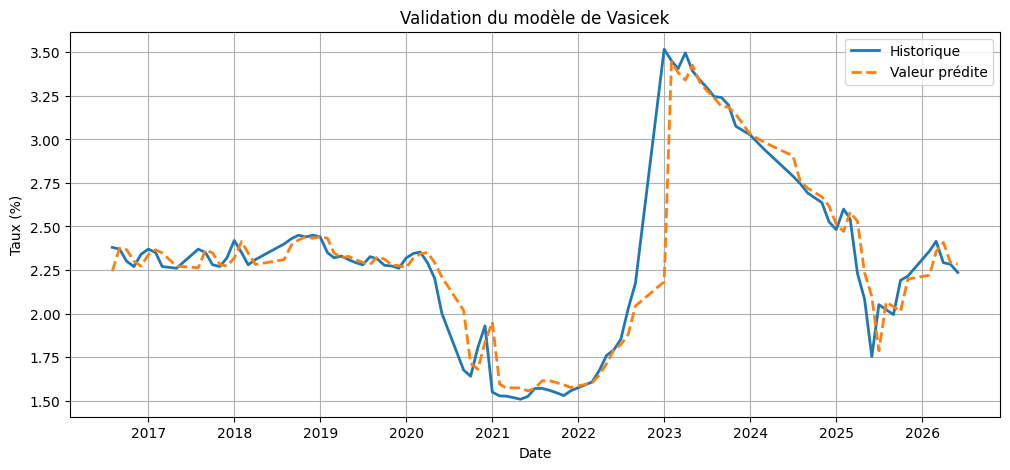

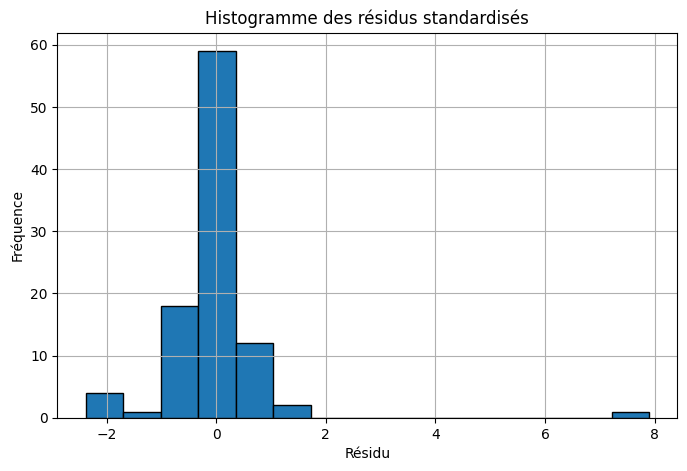

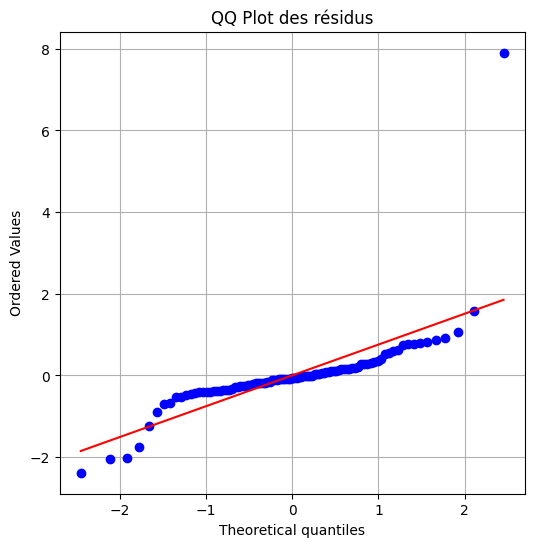

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import shapiro, probplot
from statsmodels.stats.diagnostic import acorr_ljungbox

# Validation du modèle de Vasicek


dt = 1/12

# Série historique utilisée pour la calibration
r = df["52S"].dropna().values / 100

# Paramètres estimés
a = a_hat
b = b_hat
sigma = sigma_hat


# Valeurs prédites (espérance conditionnelle)


r_pred = []

for i in range(len(r)-1):

    m = r[i] * np.exp(-a*dt) + b * (1 - np.exp(-a*dt))

    r_pred.append(m)

r_pred = np.array(r_pred)

r_real = r[1:]


# Résidus


residus = r_real - r_pred

# Résidus standardisés

variance = (sigma**2)/(2*a) * (1-np.exp(-2*a*dt))

residus_std = residus / np.sqrt(variance)

# RMSE


rmse = np.sqrt(np.mean((r_real-r_pred)**2))

print("="*60)
print("VALIDATION DU MODELE DE VASICEK")
print("="*60)

print(f"RMSE : {rmse*100:.6f} %")

print()

print("Moyenne historique      :", np.mean(r_real)*100)

print("Moyenne prédite         :", np.mean(r_pred)*100)

print()

print("Variance historique     :", np.var(r_real))

print("Variance résidus        :", np.var(residus))

print()

print("Volatilité historique   :", np.std(r_real)*100)

print("Volatilité résidus      :", np.std(residus)*100)


# Test de normalité


print("\n"+"="*60)
print("TEST DE SHAPIRO-WILK")
print("="*60)

stat,p = shapiro(residus_std)

print("Statistique :",stat)

print("p-value :",p)

if p>0.05:
    print("Les résidus suivent une loi normale.")
else:
    print("Les résidus ne suivent pas une loi normale.")


# Test de Ljung-Box


print("\n"+"="*60)
print("TEST DE LJUNG-BOX")
print("="*60)

lb = acorr_ljungbox(residus_std,lags=[10],return_df=True)

print(lb)

# Graphique Historique vs Prédiction


plt.figure(figsize=(12,5))

plt.plot(df["Date"].dropna().iloc[1:],r_real*100,
         label="Historique",
         linewidth=2)

plt.plot(df["Date"].dropna().iloc[1:],r_pred*100,
         '--',
         linewidth=2,
         label="Valeur prédite")

plt.title("Validation du modèle de Vasicek")

plt.xlabel("Date")

plt.ylabel("Taux (%)")

plt.grid(True)

plt.legend()

plt.show()

# Histogramme des résidus


plt.figure(figsize=(8,5))

plt.hist(residus_std,
         bins=15,
         edgecolor="black")

plt.title("Histogramme des résidus standardisés")

plt.xlabel("Résidu")

plt.ylabel("Fréquence")

plt.grid(True)

plt.show()

# QQ Plot

plt.figure(figsize=(6,6))

probplot(residus_std,
         dist="norm",
         plot=plt)

plt.title("QQ Plot des résidus")

plt.grid(True)

plt.show()

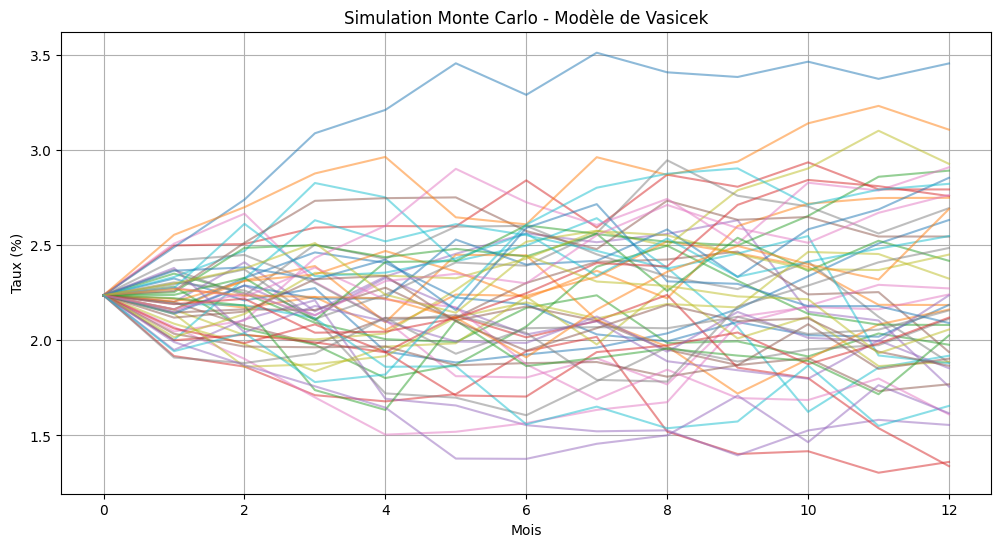

Dernier taux observé : 2.236 %
Moyenne simulée à 1 an : 2.2776402573077728 %
Écart-type simulé : 0.43661647779751794 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Paramètres estimés

a = a_hat
b = b_hat
sigma = sigma_hat

# Dernier taux observé (52 semaines)
r0 = r[-1]

# Horizon : 1 an
T = 1

# Pas mensuel
dt = 1/12

# Nombre de pas
N = int(T/dt)

# Nombre de simulations
M = 10000

# Matrice des simulations

rates = np.zeros((N+1, M))

rates[0, :] = r0


# Simulation exacte de Vasicek


np.random.seed(42)

for t in range(N):

    Z = np.random.normal(size=M)

    mean = (
        rates[t] * np.exp(-a*dt)
        + b*(1-np.exp(-a*dt))
    )

    variance = (
        sigma**2/(2*a)
    ) * (1-np.exp(-2*a*dt))

    rates[t+1] = mean + np.sqrt(variance)*Z


# Affichage


plt.figure(figsize=(12,6))

for i in range(50):
    plt.plot(rates[:, i]*100, alpha=0.5)

plt.title("Simulation Monte Carlo - Modèle de Vasicek")
plt.xlabel("Mois")
plt.ylabel("Taux (%)")
plt.grid(True)

plt.show()


# Statistiques finales


print("Dernier taux observé :", r0*100, "%")
print("Moyenne simulée à 1 an :", np.mean(rates[-1])*100, "%")
print("Écart-type simulé :", np.std(rates[-1])*100, "%")

In [ ]:
import numpy as np
import pandas as pd

# ==========================================================
# Lecture du portefeuille Bootstrap
# ==========================================================

portfolio = pd.read_excel(
    "Courbe_Zero_Coupon_Bootstrap.xlsx",
    sheet_name="Sheet1"
)

# ==========================================================
# Fonctions Vasicek
# ==========================================================

def B(a, tau):
    return (1 - np.exp(-a * tau)) / a

def A(a, b, sigma, tau):

    Bt = B(a, tau)

    return np.exp(
        (b - sigma**2/(2*a*a))*(Bt-tau)
        - (sigma**2 * Bt**2)/(4*a)
    )

# ==========================================================
# Valeur actuelle
# ==========================================================

V0 = portfolio["Prix"].sum()

# ==========================================================
# Dernier taux simulé
# ==========================================================

r_t = rates[-1]

nb_scenarios = len(r_t)

# ==========================================================
# Résultats
# ==========================================================

resultats = []

for s in range(nb_scenarios):

    taux = r_t[s]

    valeur_portefeuille = 0

    for _, row in portfolio.iterrows():

        T = row["Maturite"]

        CF = row["Flux final"]

        tau = max(T-1,0)

        if tau==0:

            prix = CF

        else:

            At = A(a,b,sigma,tau)

            Bt = B(a,tau)

            prix = CF*At*np.exp(-Bt*taux)

        valeur_portefeuille += prix

    perte = V0 - valeur_portefeuille

    resultats.append({

        "Scenario":s+1,

        "Taux simulé (%)":taux*100,

        "Valeur portefeuille":valeur_portefeuille,

        "Perte":perte

    })


# DataFrame


df_mc = pd.DataFrame(resultats)

# VaR

VaR95 = np.percentile(df_mc["Perte"],95)

VaR99 = np.percentile(df_mc["Perte"],99)

print("="*60)
print("VaR95 :",VaR95)
print("VaR99 :",VaR99)

# Ajouter les colonnes VaR


df_mc["VaR95"] = VaR95
df_mc["VaR99"] = VaR99

# Sauvegarde


df_mc.to_excel(
    "Simulation_MonteCarlo_Complète.xlsx",
    index=False
)

print(df_mc.head())

print("\nFichier enregistré : Simulation_MonteCarlo_Complète.xlsx")

VaR95 : 3190.5354323113793
VaR99 : 3578.0521092749796
   Scenario  Taux simulé (%)  Valeur portefeuille        Perte        VaR95  \
0         1         2.631302        504745.317408  2716.682671  3190.535432   
1         2         2.184935        505323.502176  2138.497903  3190.535432   
2         3         1.976178        505594.838776  1867.161303  3190.535432   
3         4         2.791636        504538.294410  2923.705669  3190.535432   
4         5         1.756534        505880.969311  1581.030768  3190.535432   

         VaR99  
0  3578.052109  
1  3578.052109  
2  3578.052109  
3  3578.052109  
4  3578.052109  

Fichier enregistré : Simulation_MonteCarlo_Complète.xlsx


VALORISATION DU PORTEFEUILLE
Valeur initiale      : 507,462.00 MAD
Valeur moyenne       : 505,204.49 MAD
Perte moyenne        : 2,257.51 MAD

VaR 95 %             : 3,190.54 MAD
VaR 99 %             : 3,578.05 MAD

CVaR 95 %            : 3,425.20 MAD
CVaR 99 %            : 3,765.17 MAD


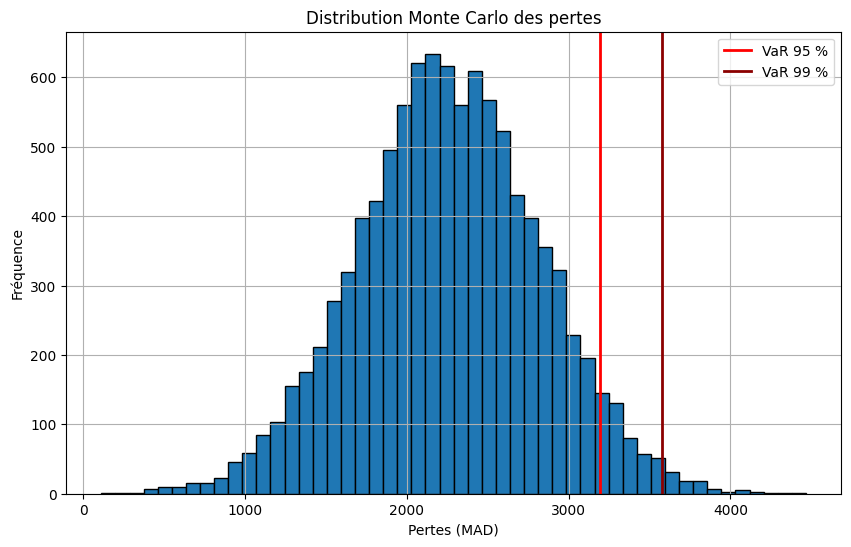

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Lecture des données


portfolio = pd.read_excel(
    "Courbe_Zero_Coupon_Bootstrap.xlsx",
    sheet_name="Sheet1"
)



# Paramètres Vasicek estimés


a = a_hat
b = b_hat
sigma = sigma_hat

# Horizon de risque
t = 1.0          # 1 an

# Dernier taux simulé de chaque scénario
r_t = rates[-1]


# Fonctions Vasicek


def B(a, tau):
    return (1 - np.exp(-a * tau)) / a

def A(a, b, sigma, tau):

    Bt = B(a, tau)

    return np.exp(
        (b - sigma**2/(2*a*a)) * (Bt - tau)
        - (sigma**2 * Bt**2)/(4*a)
    )


# Valeur actuelle du portefeuille


V0 = portfolio["Prix"].sum()


# Valorisation Monte Carlo


nb_scenarios = len(r_t)

portfolio_values = np.zeros(nb_scenarios)

for s in range(nb_scenarios):

    valeur = 0.0

    r = r_t[s]

    for _, row in portfolio.iterrows():

        T = row["Maturite"]

        CF = row["Flux final"]

        # Maturité restante après 1 an
        tau = max(T - t, 0)

        if tau == 0:
            prix = CF
        else:
            At = A(a, b, sigma, tau)
            Bt = B(a, tau)

            prix = CF * At * np.exp(-Bt * r)

        valeur += prix

    portfolio_values[s] = valeur


# Distribution des pertes


losses = V0 - portfolio_values

# VaR

VaR95 = np.percentile(losses, 95)
VaR99 = np.percentile(losses, 99)

# Expected Shortfall

CVaR95 = losses[losses >= VaR95].mean()
CVaR99 = losses[losses >= VaR99].mean()

# Résultats

print("="*60)
print("VALORISATION DU PORTEFEUILLE")
print("="*60)

print(f"Valeur initiale      : {V0:,.2f} MAD")
print(f"Valeur moyenne       : {portfolio_values.mean():,.2f} MAD")
print(f"Perte moyenne        : {losses.mean():,.2f} MAD")

print()

print(f"VaR 95 %             : {VaR95:,.2f} MAD")
print(f"VaR 99 %             : {VaR99:,.2f} MAD")

print()

print(f"CVaR 95 %            : {CVaR95:,.2f} MAD")
print(f"CVaR 99 %            : {CVaR99:,.2f} MAD")


# Histogramme

plt.figure(figsize=(10,6))

plt.hist(losses, bins=50, edgecolor="black")

plt.axvline(VaR95,
            color="red",
            linewidth=2,
            label="VaR 95 %")

plt.axvline(VaR99,
            color="darkred",
            linewidth=2,
            label="VaR 99 %")

plt.xlabel("Pertes (MAD)")
plt.ylabel("Fréquence")
plt.title("Distribution Monte Carlo des pertes")
plt.grid(True)
plt.legend()

plt.show()

Paramètres estimés
0.49994509378539276 0.024072792952509116 0.006054767085488162

========= BACKTEST =========
RMSE : 0.1590%
MAE  : 0.1217%
R²   : 0.4515
        Date  Réel (%)  Prévu (%)  Erreur (%)
0 2025-01-01     2.482   2.522115   -0.040115
1 2025-02-01     2.600   2.478951    0.121049
2 2025-03-01     2.543   2.592136   -0.049136
3 2025-04-01     2.231   2.537462   -0.306462
4 2025-05-01     2.084   2.238193   -0.154193


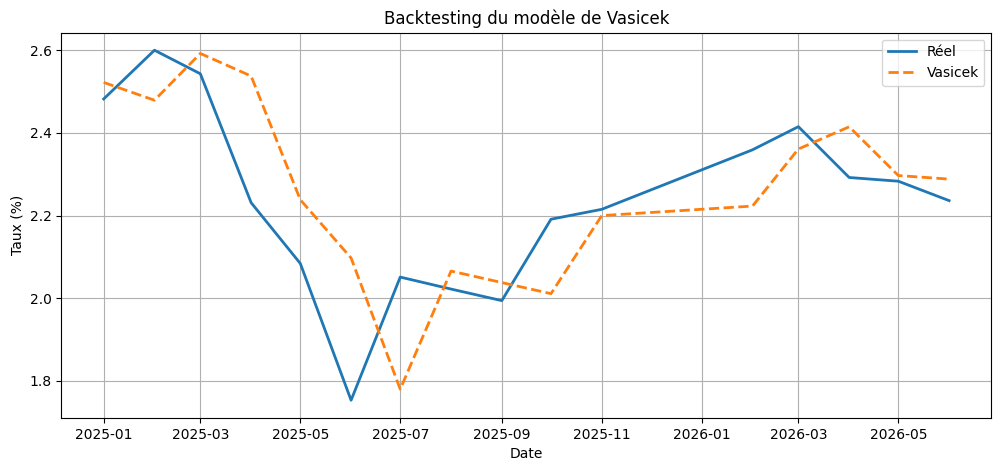

Nombre total : 98
Train : 82
Test : 16

===== TRAIN =====
          Date    52S
0   2016-07-01  2.240
1   2016-08-01  2.380
2   2016-09-01  2.370
3   2016-10-01  2.300
4   2016-11-01  2.270
..         ...    ...
96  2024-07-01  2.789
97  2024-08-01  2.746
98  2024-09-01  2.693
100 2024-11-01  2.637
101 2024-12-01  2.527

[82 rows x 2 columns]

===== TEST =====
          Date    52S
102 2025-01-01  2.482
103 2025-02-01  2.600
104 2025-03-01  2.543
105 2025-04-01  2.231
106 2025-05-01  2.084
107 2025-06-01  1.753
108 2025-07-01  2.051
109 2025-08-01  2.022
110 2025-09-01  1.994
111 2025-10-01  2.191
112 2025-11-01  2.215
115 2026-02-01  2.359
116 2026-03-01  2.415
117 2026-04-01  2.292
118 2026-05-01  2.283
119 2026-06-01  2.236


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================================
# Lecture des données
# ==========================================================

df = pd.read_excel("historique.xlsx", sheet_name="Donnees_BKAM")
df = df[["Date", "52S"]].dropna()
df["Date"] = pd.to_datetime(df["Date"])

dt = 1/12

# ==========================================================
# Séparation Calibration / Test
# 80% calibration - 20% backtest
# ==========================================================

split = int(len(df)*0.8)

train = df[df["Date"] < "2025-01-01"]

test = df[df["Date"] >= "2025-01-01"]
r_train = train["52S"].values/100
r_test = test["52S"].values/100

# ==========================================================
# Maximum Likelihood
# ==========================================================

def negative_log_likelihood(params):

    a,b,sigma=params

    if a<=0 or sigma<=0:
        return 1e20

    nll=0

    for i in range(len(r_train)-1):

        rt=r_train[i]
        rt1=r_train[i+1]

        m=rt*np.exp(-a*dt)+b*(1-np.exp(-a*dt))

        v=(sigma**2)/(2*a)*(1-np.exp(-2*a*dt))

        nll+=0.5*np.log(2*np.pi*v)
        nll+=((rt1-m)**2)/(2*v)

    return nll

result=minimize(
    negative_log_likelihood,
    [0.5,np.mean(r_train),np.std(r_train)],
    method="L-BFGS-B",
    bounds=[
        (1e-6,10),
        (0,0.20),
        (1e-6,1)
    ]
)

a_hat,b_hat,sigma_hat=result.x

print("Paramètres estimés")
print(a_hat,b_hat,sigma_hat)

# ==========================================================
# Backtest
# ==========================================================

predictions=[]

r_previous=r_train[-1]

for real_rate in r_test:

    prediction=(
        r_previous*np.exp(-a_hat*dt)
        +b_hat*(1-np.exp(-a_hat*dt))
    )

    predictions.append(prediction)

    # mise à jour avec la vraie observation
    r_previous=real_rate

predictions=np.array(predictions)

# ==========================================================
# Résultats
# ==========================================================

rmse=np.sqrt(mean_squared_error(r_test,predictions))
mae=mean_absolute_error(r_test,predictions)
r2=r2_score(r_test,predictions)

print("\n========= BACKTEST =========")
print(f"RMSE : {rmse*100:.4f}%")
print(f"MAE  : {mae*100:.4f}%")
print(f"R²   : {r2:.4f}")

# ==========================================================
# Tableau
# ==========================================================

backtest=pd.DataFrame({

    "Date":test["Date"].values,
    "Réel (%)":r_test*100,
    "Prévu (%)":predictions*100,
    "Erreur (%)":(r_test-predictions)*100

})

backtest.to_excel("Backtest_Vasicek.xlsx",index=False)

print(backtest.head())

# ==========================================================
# Graphique
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(backtest["Date"],backtest["Réel (%)"],label="Réel",linewidth=2)

plt.plot(backtest["Date"],backtest["Prévu (%)"],
         '--',label="Vasicek",linewidth=2)

plt.legend()

plt.grid(True)

plt.title("Backtesting du modèle de Vasicek")

plt.xlabel("Date")

plt.ylabel("Taux (%)")

plt.show()
print("Nombre total :", len(df))
print("Train :", len(train))
print("Test :", len(test))

print("\n===== TRAIN =====")
print(train)

print("\n===== TEST =====")
print(test)

Valeur actuelle : 507462.0 MAD
Taux actuel : 2.2017 %

  Scenario  Taux (%)  Valeur portefeuille        Perte  Variation (%)
0   Normal  2.201691        505301.749503  2160.250576      -0.425697
1  -100 pb  1.201691        506606.708156   855.291923      -0.168543
2  +100 pb  3.201691        504010.412826  3451.587253      -0.680167
3  +200 pb  4.201691        502732.541427  4729.458652      -0.931983
4  +300 pb  5.201691        501467.980441  5994.019638      -1.181176

Fichier créé : Stress_Test_Portefeuille.xlsx


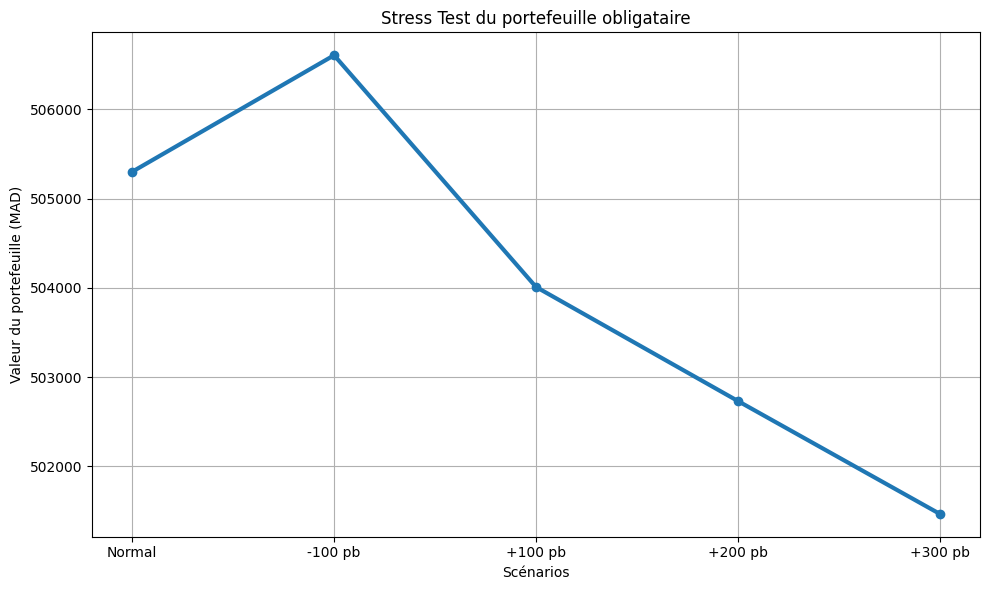

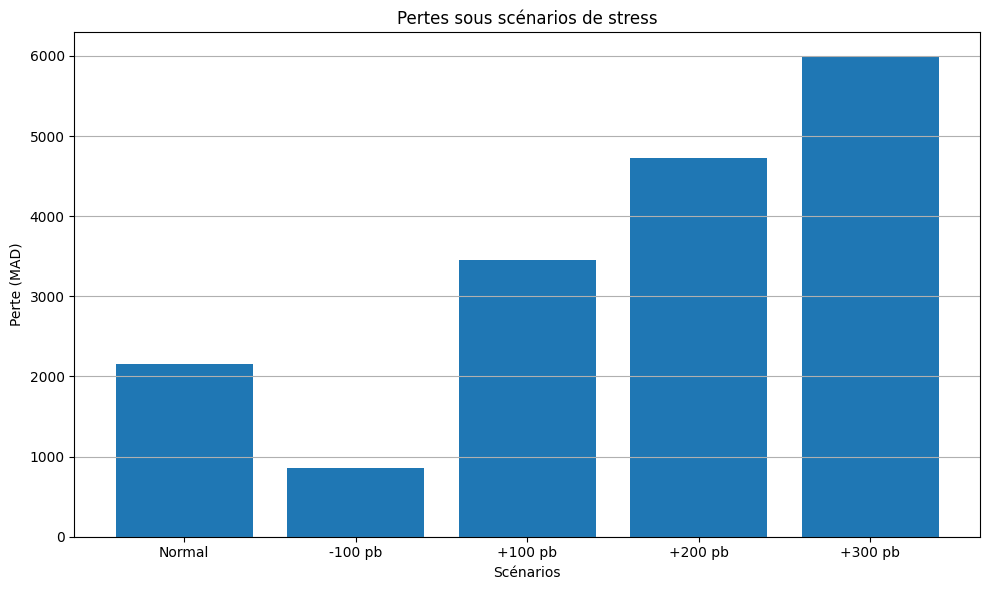

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Lecture du portefeuille
# ==========================================================
portfolio = pd.read_excel(
    "Courbe_Zero_Coupon_Bootstrap.xlsx",
    sheet_name="Sheet1"
)

# ==========================================================
# Paramètres Vasicek
# ==========================================================

a = a_hat
b = b_hat
sigma = sigma_hat

# ==========================================================
# Fonctions Vasicek
# ==========================================================

def B(a, tau):
    return (1 - np.exp(-a * tau)) / a

def A(a, b, sigma, tau):

    Bt = B(a, tau)

    return np.exp(
        (b - sigma**2/(2*a*a)) * (Bt - tau)
        - (sigma**2 * Bt**2)/(4*a)
    )

# ==========================================================
# Valeur actuelle du portefeuille
# ==========================================================

V0 = portfolio["Prix"].sum()

print("="*60)
print("Valeur actuelle :", round(V0,2),"MAD")

# ==========================================================
# Taux actuel
# ==========================================================

r0 = r

print("Taux actuel :", round(r0*100,4),"%")

# ==========================================================
# Scénarios de stress (points de base)
# ==========================================================

stress = {

    "Normal":0,

    "-100 pb":-0.01,

    "+100 pb":0.01,

    "+200 pb":0.02,

    "+300 pb":0.03

}

# ==========================================================
# Calcul
# ==========================================================

resultats=[]

for nom,choc in stress.items():

    r_stress = r0 + choc

    valeur = 0

    for _,row in portfolio.iterrows():

        T = row["Maturite"]

        CF = row["Flux final"]

        if T<=1:

            prix = CF

        else:

            tau = T-1

            At=A(a,b,sigma,tau)

            Bt=B(a,tau)

            prix = CF*At*np.exp(-Bt*r_stress)

        valeur += prix

    perte = V0-valeur

    variation = (valeur-V0)/V0*100

    resultats.append({

        "Scenario":nom,

        "Taux (%)":r_stress*100,

        "Valeur portefeuille":valeur,

        "Perte":perte,

        "Variation (%)":variation

    })

# ==========================================================
# DataFrame
# ==========================================================

stress_df=pd.DataFrame(resultats)

print()

print(stress_df)

# ==========================================================
# Sauvegarde Excel
# ==========================================================

stress_df.to_excel(

    "Stress_Test_Portefeuille.xlsx",

    index=False

)

print()

print("Fichier créé : Stress_Test_Portefeuille.xlsx")

# ==========================================================
# Graphique
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(

    stress_df["Scenario"],

    stress_df["Valeur portefeuille"],

    marker="o",

    linewidth=3

)

plt.title("Stress Test du portefeuille obligataire")

plt.xlabel("Scénarios")

plt.ylabel("Valeur du portefeuille (MAD)")

plt.grid(True)

plt.tight_layout()

plt.show()

# ==========================================================
# Graphique des pertes
# ==========================================================

plt.figure(figsize=(10,6))

plt.bar(

    stress_df["Scenario"],

    stress_df["Perte"]

)

plt.title("Pertes sous scénarios de stress")

plt.xlabel("Scénarios")

plt.ylabel("Perte (MAD)")

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import DateOffset


portfolio = pd.read_excel(
    "mon_portefeuille (1).xlsx",
    sheet_name="mon_portefeuille"
)


# supprimer la ligne TOTAL
portfolio = portfolio[
    portfolio["ID"].apply(lambda x: str(x).isdigit())
]


date_valo = pd.Timestamp("2026-07-20")


cashflows = []


for _, row in portfolio.iterrows():

    ID = row["ID"]

    nominal = row["Nominal (MAD)"]

    coupon_rate = row["Taux facial (%)"] / 100

    date_jouissance = pd.to_datetime(
        row["Date de jouissance"]
    )

    date_echeance = pd.to_datetime(
        row["Date d'échéance"]
    )


    coupon = nominal * coupon_rate


    date_flux = date_jouissance + DateOffset(years=1)


    while date_flux < date_echeance:

        if date_flux > date_valo:

            T = (
                date_flux - date_valo
            ).days / 365


            cashflows.append([
                ID,
                date_flux,
                T,
                coupon
            ])


        date_flux += DateOffset(years=1)



    # dernier flux = coupon + remboursement nominal

    if date_echeance > date_valo:

        T = (
            date_echeance - date_valo
        ).days / 365


        cashflows.append([
            ID,
            date_echeance,
            T,
            coupon + nominal
        ])



cashflows = pd.DataFrame(
    cashflows,
    columns=[
        "ID",
        "Date flux",
        "Maturite",
        "Flux"
    ]
)


print(cashflows)

   ID  Date flux  Maturite      Flux
0   1 2026-08-17  0.076712  102250.0
1   2 2026-11-16  0.326027  102250.0
2   3 2027-02-15  0.575342  102300.0
3   4 2026-09-20  0.169863    2300.0
4   4 2027-09-20  1.169863  102300.0
5   5 2027-04-15  0.736986    2750.0
6   5 2028-04-15  1.739726    2750.0
7   5 2029-04-15  2.739726    2750.0
8   5 2030-04-15  3.739726  102750.0


In [ ]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d


# ============================================================
# 1. PARAMÈTRES
# ============================================================

fichier_portefeuille = "mon_portefeuille (1).xlsx"
fichier_historique = "historique_BDT_nettoye.xlsx"

date_valo = pd.Timestamp("2026-07-20")

# VaR obtenues précédemment par Monte Carlo
VaR95 = 3190.5354323113793
VaR99 = 3578.0521092749796


# ============================================================
# 2. CHARGEMENT DU PORTEFEUILLE
# ============================================================

portfolio = pd.read_excel(
    fichier_portefeuille,
    sheet_name="mon_portefeuille"
)

# Supprimer les lignes non numériques
portfolio = portfolio[
    pd.to_numeric(portfolio["ID"], errors="coerce").notna()
].copy()

portfolio["ID"] = pd.to_numeric(
    portfolio["ID"],
    errors="coerce"
).astype(int)


print("Portefeuille chargé :")
print(
    portfolio[
        [
            "ID",
            "Nominal (MAD)",
            "Date de jouissance",
            "Date d'échéance",
            "Taux facial (%)"
        ]
    ]
)


# ============================================================
# 3. GÉNÉRATION DE TOUS LES CASH-FLOWS
# ============================================================

cashflows = []

for _, row in portfolio.iterrows():

    ID = row["ID"]

    nominal = float(row["Nominal (MAD)"])

    taux_coupon = float(
        row["Taux facial (%)"]
    ) / 100

    date_jouissance = pd.to_datetime(
        row["Date de jouissance"],
        dayfirst=True
    )

    date_echeance = pd.to_datetime(
        row["Date d'échéance"],
        dayfirst=True
    )

    # Fréquence annuelle
    coupon = nominal * taux_coupon

    # Première date de coupon
    date_flux = date_jouissance + pd.DateOffset(years=1)

    # Coupons intermédiaires
    while date_flux < date_echeance:

        if date_flux > date_valo:

            maturite = (
                date_flux - date_valo
            ).days / 365

            cashflows.append([
                ID,
                date_flux,
                maturite,
                coupon
            ])

        date_flux += pd.DateOffset(years=1)

    # Dernier flux :
    # coupon + remboursement du nominal

    if date_echeance > date_valo:

        maturite = (
            date_echeance - date_valo
        ).days / 365

        cashflows.append([
            ID,
            date_echeance,
            maturite,
            coupon + nominal
        ])


cashflows = pd.DataFrame(
    cashflows,
    columns=[
        "ID",
        "Date flux",
        "Maturite",
        "Flux"
    ]
)


print("\n============================================================")
print("CASH-FLOWS COMPLETS")
print("============================================================")

print(cashflows)


# ============================================================
# 4. CHARGEMENT DES DONNÉES HISTORIQUES
# ============================================================

historique = pd.read_excel(
    fichier_historique
)


# ============================================================
# 5. NORMALISATION DES NOMS DE COLONNES
# ============================================================

# Si ton fichier contient les noms longs
renommage = {
    "13 semaines": "13S",
    "26 semaines": "26S",
    "52 semaines": "52S",
    "2 ans": "2A",
    "5 ans": "5A",
    "10 ans": "10A",
    "15 ans": "15A",
    "20 ans": "20A",
    "30 ans": "30A"
}

historique = historique.rename(
    columns=renommage
)


colonnes = [
    "13S",
    "26S",
    "52S",
    "2A",
    "5A",
    "10A",
    "15A",
    "20A",
    "30A"
]


# ============================================================
# 6. CONVERSION DES TAUX EN NUMÉRIQUE
# ============================================================

for col in colonnes:

    historique[col] = (
        historique[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace("%", "", regex=False)
        .replace("-", np.nan)
    )

    historique[col] = pd.to_numeric(
        historique[col],
        errors="coerce"
    )


# ============================================================
# 7. MATURITÉS DES TAUX HISTORIQUES
# ============================================================

maturites_hist = np.array([
    13/52,
    26/52,
    1,
    2,
    5,
    10,
    15,
    20,
    30
])


# ============================================================
# 8. MATURITÉS DES 5 OBLIGATIONS
# ============================================================

maturites_portefeuille = np.array([
    0.076660,
    0.325804,
    0.574949,
    1.169062,
    3.737166
])


# ============================================================
# 9. CONSTRUCTION DES COURBES HISTORIQUES
# ============================================================

courbes_historiques = []

dates_historiques = []


for _, row in historique.iterrows():

    taux = row[colonnes].values.astype(float)

    # Garder uniquement les taux disponibles
    mask = ~np.isnan(taux)

    x = maturites_hist[mask]

    y = taux[mask] / 100


    # Il faut au moins deux points
    if len(x) >= 2:

        interpolation = interp1d(
            x,
            y,
            kind="linear",
            fill_value="extrapolate"
        )

        courbe = interpolation(
            maturites_portefeuille
        )

        courbes_historiques.append(courbe)

        dates_historiques.append(
            row["Date"]
        )


courbes_historiques = np.array(
    courbes_historiques
)


print("\n============================================================")
print("COURBES HISTORIQUES")
print("============================================================")

print(
    "Nombre de courbes :",
    len(courbes_historiques)
)

print(
    "Dimension :",
    courbes_historiques.shape
)


# ============================================================
# 10. VALEUR ACTUELLE DU PORTEFEUILLE
# ============================================================

# Utilisation du prix actuel déjà calculé
V0 = portfolio["Prix obligation"].sum()


print("\nValeur actuelle du portefeuille :")
print(f"{V0:,.2f} MAD")


# ============================================================
# 11. RÉÉVALUATION HISTORIQUE AVEC TOUS LES CASH-FLOWS
# ============================================================

valeurs_historiques = []


for courbe in courbes_historiques:

    valeur_portefeuille = 0


    # Chaque cash-flow est actualisé
    for _, cf in cashflows.iterrows():

        T = cf["Maturite"]

        flux = cf["Flux"]


        # Interpolation du taux zéro historique
        # correspondant à la maturité du cash-flow

        z = np.interp(
            T,
            maturites_portefeuille,
            courbe
        )


        # Discount Factor

        DF = 1 / ((1 + z) ** T)


        # Valeur actuelle du cash-flow

        valeur_portefeuille += (
            flux * DF
        )


    valeurs_historiques.append(
        valeur_portefeuille
    )


valeurs_historiques = np.array(
    valeurs_historiques
)


print("\n============================================================")
print("RÉÉVALUATION HISTORIQUE")
print("============================================================")

print(
    "Nombre de valeurs :",
    len(valeurs_historiques)
)

print("\nPremières valeurs :")

print(
    valeurs_historiques[:10]
)


# ============================================================
# 12. CONSTRUCTION DU TABLEAU DE BACKTESTING
# ============================================================

backtest = pd.DataFrame({

    "Date": dates_historiques,

    "Valeur historique": valeurs_historiques
})


# ============================================================
# 13. CALCUL DES PERTES
# ============================================================

backtest["Perte historique"] = (
    V0
    -
    backtest["Valeur historique"]
)


# ============================================================
# 14. AJOUT DES VaR
# ============================================================

backtest["VaR95"] = VaR95

backtest["VaR99"] = VaR99


# ============================================================
# 15. IDENTIFICATION DES EXCEPTIONS
# ============================================================

backtest["Exception95"] = (
    backtest["Perte historique"] > VaR95
).astype(int)


backtest["Exception99"] = (
    backtest["Perte historique"] > VaR99
).astype(int)


# ============================================================
# 16. RÉSULTATS
# ============================================================

nombre_exceptions_95 = (
    backtest["Exception95"].sum()
)

nombre_exceptions_99 = (
    backtest["Exception99"].sum()
)


print("\n============================================================")
print("BACKTESTING VaR PAR RÉÉVALUATION HISTORIQUE")
print("============================================================")

print(
    f"Valeur actuelle : {V0:,.2f} MAD"
)

print(
    f"Nombre observations : {len(backtest)}"
)

print(
    f"VaR95 : {VaR95:,.2f} MAD"
)

print(
    f"VaR99 : {VaR99:,.2f} MAD"
)

print(
    f"Exceptions VaR95 : {nombre_exceptions_95}"
)

print(
    f"Exceptions VaR99 : {nombre_exceptions_99}"
)


# ============================================================
# 17. AFFICHER UNIQUEMENT LES EXCEPTIONS
# ============================================================

print("\n============================================================")
print("EXCEPTIONS VaR95")
print("============================================================")

print(
    backtest[
        backtest["Exception95"] == 1
    ]
)


# ============================================================
# 18. EXPORT EXCEL
# ============================================================

fichier_sortie = (
    "Backtesting_VaR_Reevaluation_Historique.xlsx"
)


backtest.to_excel(
    fichier_sortie,
    index=False
)


print("\nFichier créé :")
print(fichier_sortie)

Portefeuille chargé :
   ID  Nominal (MAD)   Date de jouissance Date d'échéance  Taux facial (%)
0   1       100000.0  2021-08-17 00:00:00      2026-08-17             2.25
1   2       100000.0  2021-11-16 00:00:00      2026-11-16             2.25
2   3       100000.0  2022-02-15 00:00:00      2027-02-15             2.30
3   4       100000.0  2022-09-20 00:00:00      2027-09-20             2.30
4   5       100000.0  2025-04-15 00:00:00      2030-04-15             2.75

CASH-FLOWS COMPLETS
   ID  Date flux  Maturite      Flux
0   1 2026-08-17  0.076712  102250.0
1   2 2026-11-16  0.326027  102250.0
2   3 2027-02-15  0.575342  102300.0
3   4 2026-09-20  0.169863    2300.0
4   4 2027-09-20  1.169863  102300.0
5   5 2027-04-15  0.736986    2750.0
6   5 2028-04-15  1.739726    2750.0
7   5 2029-04-15  2.739726    2750.0
8   5 2030-04-15  3.739726  102750.0

COURBES HISTORIQUES
Nombre de courbes : 120
Dimension : (120, 5)

Valeur actuelle du portefeuille :
507,462.00 MAD

RÉÉVALUATION HISTORI